# FDM Data Generation — v2: Diurnal Time-Varying Boundary Conditions
**Sindh Research Project 321 — Stage 1 (upgraded)**

This notebook replaces the constant-forcing v1 solver. **Run top to bottom** (Runtime → Run all). All validations execute before the sweep; any failure stops execution.

**What changed vs. v1** (details in the docstring of the next cell):
1. **Diurnal forcing** — `T_out(t)` sinusoid (max at 15:00, fixed 12 K swing) and `G_s(t)` half-sine (06:00–18:00). Same 9 parameters, same ranges; `T_out_C` is now the **daily maximum**, `G_s` the **solar-noon peak**.
2. **Periodic steady state** — 5 identical days simulated; the **final day** is the dataset field (still 65 × 121). Per-sample periodicity metric saved.
3. **Second-order time-varying CN** — rhs uses time-averaged forcing.
4. **~100× faster solver** — LU-prefactored constant tridiagonal system (full 1500-sample sweep ≈ 10–20 min on Colab CPU).
5. **New dynamic metrics** — time lag \[h\] and decrement factor \[–\] vs. sol-air temperature (ISO 13786-style), per material and per sample.
6. **Smart initial condition** — steady state of the time-mean forcing (spin-up accelerator; final day verified IC-independent).
7. **New validations** — C: space-time convergence of the *time-varying* problem vs. a fine reference; D: periodicity + IC-independence. A (Dirichlet MMS) and B (Robin zero-drift) retained from v1.

**Expected runtime:** validations ≈ 2–4 min, sweep ≈ 10–20 min. Output: `sindh_dataset_diurnal.npz`, `material_ranking_diurnal.csv`, `fdm_convergence_diurnal.csv`, three PNG figures.

In [1]:
"""
Sindh Research Project 321 — Stage 1 (v2): FDM Data Generation
DIURNAL TIME-VARYING BOUNDARY CONDITIONS
=====================================================================
Changes vs. v1 (constant-forcing solver) — all numerics of v1 verified
and retained; regression test in Validation B/C confirms equivalence:

 [C1] T_out(t), G_s(t) are diurnal profiles. Same 9 parameters, same
      ranges; two REINTERPRETED:
        T_out_C : DAILY MAXIMUM outdoor air temperature [deg C]
        G_s     : PEAK (solar-noon) irradiance          [W/m^2]
 [C2] N_DAYS = 5 identical days are simulated; the FINAL day (periodic
      quasi-steady state) is extracted as the dataset field (65 x 121).
      Per-sample periodicity metric = max |T_L(day4) - T_L(day5)|.
 [C3] CN rhs uses TIME-AVERAGED forcing (old+new step) — preserves
      second-order accuracy in time under time-varying BCs.
 [C4] Constant tridiagonal A is LU-prefactored once per run
      (~400 ms/run -> full 1500-sample sweep in ~10-20 min).
 [C5] New final-day dynamic metrics per ISO-13786 practice:
      time lag [h] and decrement factor [-] w.r.t. sol-air temperature.
 [C6] Smart initial condition: steady state of the time-MEAN forcing
      (exact time-mean of the periodic solution for a linear problem)
      -> spin-up accelerated; final day is IC-independent.
 [C7] New validations: (C) time-varying space-time convergence vs a
      fine reference; (D) periodicity + IC-independence.

Forcing model (t = 0 at sunrise 06:00; tau_d = t mod 24 h):
  G_s(t)   = G_peak sin(pi tau_d / 12h)   for tau_d < 12 h, else 0
  T_out(t) = (T_max - A) + A sin(2 pi (tau_d - 3h) / 24h),
             2A = DELTA_DIURNAL fixed  ->  max at 15:00, min at 03:00
  T_in     = constant (parametric, unchanged)

Output: sindh_dataset_diurnal.npz
  mu (1500,9) | T_field (1500,65,121) final-day [K] | J_series (1500,121)
  J_peak, time_lag_h, decrement, periodicity_K (1500,) | x_grid | t_save
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
from scipy.linalg import lu_factor, lu_solve
import csv, time, os
from google.colab import drive
drive.mount('/content/drive')

# ================================================================
# SECTION 1 — Constants
# ================================================================

H_OUT   = 25.0            # W/m^2/K  outdoor combined HTC (ISO 6946)
H_IN    = 7.69            # W/m^2/K  indoor combined HTC  (ISO 6946, R_si = 0.13)
ALPHA_S = 0.7             # -        solar absorptivity

DAY_S         = 24.0 * 3600.0   # s
DAYLIGHT_S    = 12.0 * 3600.0   # s   sunrise -> sunset half-sine window
DELTA_DIURNAL = 12.0            # K   fixed total diurnal air-temp swing
                                 #     (typical Sindh summer Tmax - Tmin,
                                 #      NASA POWER, upper-Sindh stations, June)
T_PEAK_LAG_S  = 3.0 * 3600.0    # s   air-temp peak at 15:00 (3 h after noon)

N_DAYS        = 5               # simulated identical days (last = dataset day)
T_INIT_LEGACY = 305.0           # K   v1 uniform IC (kept for the
                                 #     IC-independence test only)

# --- FDM grid (production settings; dt = 21.6 s as in v1) ---
N_SPACE       = 64              # spatial intervals -> 65 nodes
STEPS_PER_DAY = 4000
N_SAVE        = 121             # final-day snapshots (every 12 min)

# --- LHS sweep ---
N_SAMPLES = 1500
SEED      = 42

# --- Parameter ranges — Table 1 (ranges UNCHANGED; [C1] reinterpretation) ---
PARAM_NAMES = ['k_dry', 'rho', 'cp', 'alpha_moist',
               'L', 'w0', 'T_out_max_C', 'T_in_C', 'G_s_peak']
PARAM_LOWER = np.array([0.20, 800,  650,  0.001, 0.15,  0,  25, 25,  200])
PARAM_UPPER = np.array([1.50, 2200, 2000, 0.010, 0.45, 30,  48, 45,  900])

MATERIALS = {
    'Mud brick (unfired)':          {'k_dry': 0.45, 'rho': 1600, 'cp': 880,  'alpha_moist': 0.005},
    'Clay-straw adobe':             {'k_dry': 0.35, 'rho': 1400, 'cp': 1000, 'alpha_moist': 0.004},
    'Lime-stabilised bamboo panel': {'k_dry': 0.25, 'rho': 900,  'cp': 1800, 'alpha_moist': 0.003},
    'Fired clay brick':             {'k_dry': 0.65, 'rho': 1800, 'cp': 840,  'alpha_moist': 0.005},
    'Lime-mud composite':           {'k_dry': 0.55, 'rho': 1500, 'cp': 900,  'alpha_moist': 0.004},
}

Mounted at /content/drive


In [2]:
# ================================================================
# SECTION 2 — k_eff and diurnal forcing                       [C1]
# ================================================================

def k_eff(k_dry, alpha_moist, w0):
    """eq:keff — computed once per run, constant in the time loop."""
    return k_dry + alpha_moist * w0


def G_s_profile(t, G_peak):
    """Half-sine clear-sky irradiance [W/m^2]; zero outside daylight."""
    tau_d = np.mod(t, DAY_S)
    return np.where(tau_d < DAYLIGHT_S,
                    G_peak * np.sin(np.pi * tau_d / DAYLIGHT_S), 0.0)


def T_out_profile(t, T_out_max_C):
    """Sinusoidal outdoor air temperature [K]:
    maximum T_out_max at 15:00, minimum at 03:00, swing DELTA_DIURNAL."""
    A = 0.5 * DELTA_DIURNAL
    tau_d = np.mod(t, DAY_S)
    return (T_out_max_C + 273.15) - A \
           + A * np.sin(2*np.pi*(tau_d - T_PEAK_LAG_S) / DAY_S)


def sol_air_profile(t, T_out_max_C, G_peak):
    """Sol-air temperature T_sa = T_out + alpha_s G_s / h_out [K] —
    the reference forcing for time lag / decrement factor."""
    return T_out_profile(t, T_out_max_C) + ALPHA_S * G_s_profile(t, G_peak) / H_OUT

# ================================================================
# SECTION 3 — Analytical Robin steady state (unchanged from v1)
# ================================================================

def analytical_robin_steady(k, L, T_out_K, T_in_K, Q_solar):
    """eq:q_robin / eq:T_robin — exact steady state under constant forcing."""
    q_star = (T_out_K + Q_solar / H_OUT - T_in_K) / (1/H_OUT + L/k + 1/H_IN)
    def T_star(x):
        return T_out_K + (Q_solar - q_star) / H_OUT - (q_star / k) * x
    return q_star, T_star

# ================================================================
# SECTION 4 — Crank-Nicolson solver: time-varying forcing [C3],
#             LU-prefactored constant system [C4]
# ================================================================

def build_cn_matrices(k, rho, cp, L, N, dt):
    """
    Assemble the CONSTANT tridiagonal CN matrices A (implicit) and B
    (explicit) with ghost-node Robin rows — identical algebra to the
    verified v1 stencil — and LU-factor A once. Only the rhs forcing
    is time-dependent.

      interior i=1..N-1 : A[i,i-/+1] = -r/2, A[i,i] = 1+r ; B mirrored
      outer row  (i=0)  : A[0,0] = 1+r(1+beta_out), A[0,1] = -r
      inner row  (i=N)  : A[N,N] = 1+r(1+beta_in),  A[N,N-1] = -r
      beta_out = h_out dx / k,  beta_in = h_in dx / k
    """
    dx = L / N
    r  = k * dt / (rho * cp * dx**2)
    beta_out = H_OUT * dx / k
    beta_in  = H_IN  * dx / k

    A = np.zeros((N+1, N+1)); B = np.zeros((N+1, N+1))
    for i in range(1, N):
        A[i, i-1] = -r/2; A[i, i] = 1 + r; A[i, i+1] = -r/2
        B[i, i-1] =  r/2; B[i, i] = 1 - r; B[i, i+1] =  r/2
    A[0, 0] = 1 + r*(1 + beta_out); A[0, 1] = -r
    B[0, 0] = 1 - r*(1 + beta_out); B[0, 1] =  r
    A[N, N] = 1 + r*(1 + beta_in);  A[N, N-1] = -r
    B[N, N] = 1 - r*(1 + beta_in);  B[N, N-1] =  r

    lu = lu_factor(A)
    Bdiags = (np.diag(B, -1), np.diag(B), np.diag(B, 1))
    return lu, Bdiags, r, dx, beta_out, beta_in


def tridiag_apply(Bdiags, T):
    """y = B @ T for tridiagonal B stored as (lower, diag, upper)."""
    Bl, Bd, Bu = Bdiags
    y = Bd * T
    y[1:]  += Bl * T[:-1]
    y[:-1] += Bu * T[1:]
    return y


def run_fdm_diurnal(mu_row, N=N_SPACE, steps_per_day=STEPS_PER_DAY,
                    n_days=N_DAYS, n_save=N_SAVE,
                    return_full_final_day=False,
                    T_out_fn=None, Q_abs_fn=None, T_init_profile=None):
    """
    One multi-day FDM simulation with diurnal (or overridden) forcing.

    mu_row = (k_dry, rho, cp, alpha_moist, L, w0,
              T_out_max_C, T_in_C, G_s_peak)

    Optional overrides (used by the validation cells):
      T_out_fn(t)       -> outdoor air temperature [K]
      Q_abs_fn(t)       -> ABSORBED solar flux alpha_s*G_s [W/m^2]
      T_init_profile(x) -> initial temperature profile [K]

    Returns x_grid, t_save, T_field (final day), metrics dict
    (J_peak [K], time_lag_h, decrement, periodicity_K), and optionally
    the full-resolution final-day traces (t_full, T_L, T_sa).
    """
    k_dry, rho, cp, alpha_moist, L, w0, T_out_max_C, T_in_C, G_s_peak = mu_row
    T_in_K = T_in_C + 273.15
    k      = k_eff(k_dry, alpha_moist, w0)

    dt      = DAY_S / steps_per_day
    n_steps = n_days * steps_per_day
    x_grid  = np.linspace(0, L, N+1)

    if T_out_fn is None:
        T_out_fn = lambda t: T_out_profile(t, T_out_max_C)
    if Q_abs_fn is None:
        Q_abs_fn = lambda t: ALPHA_S * G_s_profile(t, G_s_peak)

    lu, Bdiags, r, dx, beta_out, beta_in = build_cn_matrices(k, rho, cp, L, N, dt)

    # Precompute forcing at every time level
    t_all  = dt * np.arange(n_steps + 1)
    Tout_K = np.asarray(T_out_fn(t_all), dtype=float)
    Qabs   = np.asarray(Q_abs_fn(t_all), dtype=float)

    # --- Initial condition [C6]: steady state of the time-MEAN forcing ---
    # (exact time-mean of the periodic solution for this linear problem;
    #  final-day results are IC-independent — verified in Validation D)
    if T_init_profile is None:
        Tout_mean = Tout_K.mean()
        Qabs_mean = Qabs.mean()
        _, T_star_mean = analytical_robin_steady(k, L, Tout_mean, T_in_K, Qabs_mean)
        T = T_star_mean(x_grid)
    else:
        T = np.asarray(T_init_profile(x_grid), dtype=float).copy()

    # --- storage bookkeeping -------------------------------------------
    final_start = (n_days - 1) * steps_per_day
    prev_start  = max(n_days - 2, 0) * steps_per_day
    save_local  = np.round(np.linspace(0, steps_per_day, n_save)).astype(int)
    save_global = final_start + save_local
    t_save      = save_local * dt                    # [s from final-day sunrise]

    T_field  = np.zeros((N+1, n_save))
    TL_final = np.zeros(steps_per_day + 1)
    TL_prev  = np.zeros(steps_per_day + 1)
    state = {'ptr': 0}

    def record(step, T):
        if prev_start <= step <= prev_start + steps_per_day:
            TL_prev[step - prev_start] = T[-1]
        if step >= final_start:
            TL_final[step - final_start] = T[-1]
            if state['ptr'] < n_save and step == save_global[state['ptr']]:
                T_field[:, state['ptr']] = T
                state['ptr'] += 1

    record(0, T)

    rhs = np.zeros(N+1)
    rhs[-1] = 2.0 * r * beta_in * T_in_K            # T_in constant
    for step in range(1, n_steps + 1):
        # [C3] time-averaged forcing preserves O(dt^2)
        rhs[0] = r * beta_out * (Tout_K[step-1] + Tout_K[step]) \
                 + r * dx * (Qabs[step-1] + Qabs[step]) / k
        T = lu_solve(lu, tridiag_apply(Bdiags, T) + rhs)
        record(step, T)

    assert state['ptr'] == n_save, "snapshot bookkeeping error"

    # --- final-day metrics [C5] ----------------------------------------
    t_full = dt * np.arange(steps_per_day + 1)
    T_sa   = T_out_fn(final_start*dt + t_full) \
             + Q_abs_fn(final_start*dt + t_full) / H_OUT

    J_peak = float(TL_final.max())
    lag_s  = float(t_full[np.argmax(TL_final)] - t_full[np.argmax(T_sa)])
    if lag_s < 0:
        lag_s += DAY_S                               # peak wrapped past midnight
    sa_swing  = float(T_sa.max() - T_sa.min())
    decrement = float((TL_final.max() - TL_final.min()) / sa_swing) \
                if sa_swing > 1e-12 else float('nan')
    period_K  = float(np.max(np.abs(TL_final - TL_prev)))

    metrics = dict(J_peak=J_peak, time_lag_h=lag_s/3600.0,
                   decrement=decrement, periodicity_K=period_K)

    if return_full_final_day:
        return x_grid, t_save, T_field, metrics, (t_full, TL_final, T_sa)
    return x_grid, t_save, T_field, metrics


def generate_lhs_samples(n=N_SAMPLES, seed=SEED):
    """LHS over the 9-D parameter space (Table 1 ranges)."""
    sampler = qmc.LatinHypercube(d=9, seed=seed)
    return qmc.scale(sampler.random(n=n), PARAM_LOWER, PARAM_UPPER)

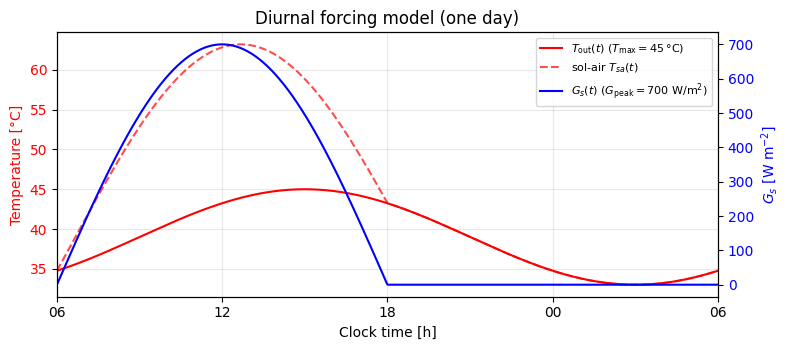

Saved: diurnal_forcing.png


In [3]:
# CELL: forcing plot
# ================================================================
# SECTION 2b — Visual check of the diurnal forcing
# ================================================================
t_plot = np.linspace(0, DAY_S, 24*60)
hours  = 6 + t_plot/3600.0                      # clock time [h]

fig, ax1 = plt.subplots(figsize=(8, 3.6))
ax1.plot(hours, T_out_profile(t_plot, 45.0) - 273.15, 'r-',
         label=r'$T_{\mathrm{out}}(t)$ ($T_{\max}=45\,°$C)')
ax1.plot(hours, sol_air_profile(t_plot, 45.0, 700.0) - 273.15, 'r--',
         label=r'sol-air $T_{sa}(t)$', alpha=0.7)
ax1.set_xlabel('Clock time [h]'); ax1.set_ylabel('Temperature [°C]', color='r')
ax1.tick_params(axis='y', labelcolor='r'); ax1.set_xlim(6, 30)
ax1.set_xticks([6, 12, 18, 24, 30]); ax1.set_xticklabels(['06', '12', '18', '00', '06'])
ax2 = ax1.twinx()
ax2.plot(hours, G_s_profile(t_plot, 700.0), 'b-',
         label=r'$G_s(t)$ ($G_{\mathrm{peak}}=700$ W/m$^2$)')
ax2.set_ylabel(r'$G_s$ [W m$^{-2}$]', color='b'); ax2.tick_params(axis='y', labelcolor='b')
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, fontsize=8, loc='upper right')
ax1.grid(alpha=0.3); plt.title('Diurnal forcing model (one day)')
plt.tight_layout(); plt.savefig('/content/drive/MyDrive/diurnal_forcing.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: diurnal_forcing.png')

## Validations
A — Dirichlet MMS spatial convergence (unchanged from v1, expected order 2.00).
B — Robin zero-drift under constant forcing (machine precision; validates the ghost-node Robin rows).
C — **New:** transient convergence of the diurnal problem vs. a fine space-time reference (validates the time-averaged forcing).
D — **New:** periodic-steady-state and IC-independence checks for the most sluggish wall in the parameter space.

In [4]:
# CELL: Validation A — Dirichlet MMS (unchanged from v1)
# ================================================================
# VALIDATION A — Dirichlet MMS spatial convergence (as in v1)
# T(x,t) = T_ss(x) + sin(pi x/L) exp(-a (pi/L)^2 t) is an exact
# solution; expected O(dx^2). Fills the manuscript convergence table.
# ================================================================
def validate_dirichlet():
    print('='*60); print('VALIDATION A — Dirichlet MMS'); print('='*60)
    k_t, rho_t, cp_t, L_t = 0.35, 1400.0, 1000.0, 0.25
    T_out_K, T_in_K = 45 + 273.15, 35 + 273.15
    a = k_t / (rho_t * cp_t)
    t_end = 12 * 3600.0
    n_steps = 2000

    def T_exact(x, t):
        return T_out_K + (T_in_K - T_out_K)*x/L_t \
               + np.sin(np.pi*x/L_t)*np.exp(-a*(np.pi/L_t)**2 * t)

    errors, grids = [], [16, 32, 64, 128]
    for N in grids:
        dx = L_t / N; dt = t_end / n_steps
        x = np.linspace(0, L_t, N+1)
        r = k_t*dt/(rho_t*cp_t*dx**2)
        A = np.zeros((N+1, N+1)); B = np.zeros((N+1, N+1)); rhs = np.zeros(N+1)
        for i in range(1, N):
            A[i, i-1] = -r/2; A[i, i] = 1+r; A[i, i+1] = -r/2
            B[i, i-1] =  r/2; B[i, i] = 1-r; B[i, i+1] =  r/2
        A[0, 0] = 1.0; rhs[0] = T_out_K
        A[N, N] = 1.0; rhs[N] = T_in_K
        lu = lu_factor(A)
        T = T_exact(x, 0.0)
        for _ in range(n_steps):
            T = lu_solve(lu, B @ T + rhs)
        err = np.max(np.abs(T - T_exact(x, t_end)))
        errors.append(err)
        print(f'  N={N:4d}  dx={dx:.5f} m  Linf error={err:.3e} K')
    print('\n  Convergence orders:')
    for i in range(1, len(grids)):
        order = np.log(errors[i-1]/errors[i]) / np.log(grids[i]/grids[i-1])
        print(f'  N={grids[i-1]:3d}->{grids[i]:3d}: order = {order:.2f} (expected 2.00)')
        assert order > 1.7, 'Dirichlet convergence broken'
    print('  PASS')
    return list(zip(grids, errors))

dirichlet_rows = validate_dirichlet()

VALIDATION A — Dirichlet MMS
  N=  16  dx=0.01562 m  Linf error=9.969e-04 K
  N=  32  dx=0.00781 m  Linf error=2.489e-04 K
  N=  64  dx=0.00391 m  Linf error=6.221e-05 K
  N= 128  dx=0.00195 m  Linf error=1.554e-05 K

  Convergence orders:
  N= 16-> 32: order = 2.00 (expected 2.00)
  N= 32-> 64: order = 2.00 (expected 2.00)
  N= 64->128: order = 2.00 (expected 2.00)
  PASS


In [5]:
# CELL: Validation B — Robin zero-drift (constant-forcing special case)
# ================================================================
# VALIDATION B — Robin BC zero-drift (constant forcing)
# Start from the exact Robin steady state under CONSTANT forcing and
# advance one full day: the field must not drift (machine precision).
# Validates the ghost-node Robin rows exactly as in v1.
# ================================================================
def validate_robin_zero_drift():
    print('='*60); print('VALIDATION B — Robin zero-drift (constant forcing)'); print('='*60)
    mu = np.array([0.35, 1400.0, 1000.0, 0.004, 0.25, 0.0, 45.0, 35.0, 700.0])
    T_out_K = 45 + 273.15; Q_abs = ALPHA_S * 700.0
    _, T_star = analytical_robin_steady(0.35, 0.25, T_out_K, 35 + 273.15, Q_abs)
    print(f'  Analytical T*(0) = {T_star(0)-273.15:.4f} °C, '
          f'T*(L) = {T_star(0.25)-273.15:.4f} °C')
    for N in [16, 32, 64, 128]:
        x, ts, Tf, met = run_fdm_diurnal(
            mu, N=N, steps_per_day=2000, n_days=1, n_save=3,
            T_out_fn=lambda t: np.full_like(np.asarray(t, float), T_out_K),
            Q_abs_fn=lambda t: np.full_like(np.asarray(t, float), Q_abs),
            T_init_profile=lambda x: T_star(x))
        drift = np.max(np.abs(Tf[:, -1] - T_star(x)))
        print(f'  N={N:4d}  drift after 24 h = {drift:.3e} K')
        assert drift < 1e-6, 'Robin BC broken'
    print('  PASS (machine precision)')

validate_robin_zero_drift()

VALIDATION B — Robin zero-drift (constant forcing)
  Analytical T*(0) = 63.2611 °C, T*(L) = 39.3526 °C
  N=  16  drift after 24 h = 7.390e-13 K
  N=  32  drift after 24 h = 3.411e-13 K
  N=  64  drift after 24 h = 3.979e-13 K
  N= 128  drift after 24 h = 5.116e-13 K
  PASS (machine precision)


In [6]:
# CELL: Validation C — time-varying convergence (NEW)
# ================================================================
# VALIDATION C — transient convergence under DIURNAL forcing [C7]
# Space and time refined together against a fine reference
# (N=256, 32000 steps/day). Tests the actual time-varying problem
# used to build the dataset, incl. the averaged-forcing CN rhs [C3].
# ================================================================
def validate_diurnal_convergence():
    print('='*60); print('VALIDATION C — diurnal transient convergence'); print('='*60)
    mu = np.array([0.35, 1400.0, 1000.0, 0.004, 0.25, 15.0, 45.0, 35.0, 700.0])
    print('  Computing fine reference (N=256, 32000 steps/day) ...')
    *_, met_ref, (t_ref, TL_ref, _) = run_fdm_diurnal(
        mu, N=256, steps_per_day=32000, return_full_final_day=True)
    rows = []
    for N, spd in [(16, 1000), (32, 2000), (64, 4000), (128, 8000)]:
        *_, met, (t_f, TL, _) = run_fdm_diurnal(
            mu, N=N, steps_per_day=spd, return_full_final_day=True)
        err = np.max(np.abs(np.interp(t_ref, t_f, TL) - TL_ref))
        epk = abs(met['J_peak'] - met_ref['J_peak'])
        rows.append((N, spd, err, epk))
        print(f'  N={N:4d} steps/day={spd:6d}  '
              f'max|T_L(t)-ref|={err:.3e} K  |Jpk-ref|={epk:.3e} K')
    print('\n  Convergence orders (on max|T_L - ref|):')
    for i in range(1, len(rows)):
        order = np.log(rows[i-1][2]/rows[i][2]) / np.log(rows[i][0]/rows[i-1][0])
        print(f'  N={rows[i-1][0]:3d}->{rows[i][0]:3d}: order = {order:.2f}')
    assert rows[2][2] < 1e-2, 'production-setting transient error too large'
    print(f'  Production settings (N=64, 4000/day): '
          f'{rows[2][2]*1000:.2f} mK on T_L(t) — PASS')
    with open('/content/drive/MyDrive/fdm_convergence_diurnal.csv', 'w', newline='') as f:
        w = csv.writer(f); w.writerow(['N', 'steps_per_day', 'Linf_TL_K', 'err_Jpeak_K'])
        w.writerows(rows)
    print('  Saved: fdm_convergence_diurnal.csv')

validate_diurnal_convergence()

VALIDATION C — diurnal transient convergence
  Computing fine reference (N=256, 32000 steps/day) ...
  N=  16 steps/day=  1000  max|T_L(t)-ref|=9.881e-03 K  |Jpk-ref|=3.656e-03 K
  N=  32 steps/day=  2000  max|T_L(t)-ref|=2.448e-03 K  |Jpk-ref|=9.156e-04 K
  N=  64 steps/day=  4000  max|T_L(t)-ref|=5.832e-04 K  |Jpk-ref|=2.188e-04 K
  N= 128 steps/day=  8000  max|T_L(t)-ref|=1.166e-04 K  |Jpk-ref|=4.379e-05 K

  Convergence orders (on max|T_L - ref|):
  N= 16-> 32: order = 2.01
  N= 32-> 64: order = 2.07
  N= 64->128: order = 2.32
  Production settings (N=64, 4000/day): 0.58 mK on T_L(t) — PASS
  Saved: fdm_convergence_diurnal.csv


In [7]:
# CELL: Validation D — periodicity + IC-independence (NEW)
# ================================================================
# VALIDATION D — periodic steady state & IC-independence [C2, C6]
# (i)  day-4 vs day-5 inner-surface difference must be small for the
#      most sluggish wall in the parameter space;
# (ii) final-day solution must be independent of the IC (smart IC vs
#      the v1 uniform 305 K IC).
# ================================================================
def validate_periodicity():
    print('='*60); print('VALIDATION D — periodicity & IC-independence'); print('='*60)
    mu_worst = np.array([0.25, 900, 1800, 0.003, 0.45, 0.0, 45.0, 35.0, 700.0])
    *_, met_s, (t1, TL1, _) = run_fdm_diurnal(mu_worst, return_full_final_day=True)
    *_, met_u, (t2, TL2, _) = run_fdm_diurnal(
        mu_worst, return_full_final_day=True,
        T_init_profile=lambda x: np.full_like(np.asarray(x, float), T_INIT_LEGACY))
    dic = np.max(np.abs(TL1 - TL2))
    print(f'  Most sluggish wall (bamboo panel, L=0.45 m):')
    print(f'    periodicity |day4-day5| (smart IC)   = {met_s["periodicity_K"]:.2e} K')
    print(f'    periodicity |day4-day5| (uniform IC) = {met_u["periodicity_K"]:.2e} K')
    print(f'    final-day |smart IC - uniform IC|    = {dic:.2e} K')
    assert met_s['periodicity_K'] < 0.05, 'wall not periodic — increase N_DAYS'
    print('  PASS — final day is a periodic steady state; '
          'per-sample periodicity_K is saved with the dataset')

validate_periodicity()

VALIDATION D — periodicity & IC-independence
  Most sluggish wall (bamboo panel, L=0.45 m):
    periodicity |day4-day5| (smart IC)   = 1.25e-02 K
    periodicity |day4-day5| (uniform IC) = 1.61e-01 K
    final-day |smart IC - uniform IC|    = 2.42e-01 K
  PASS — final day is a periodic steady state; per-sample periodicity_K is saved with the dataset


  k_eff = 0.4100 W/m/K
  J_peak = 37.45 °C   time lag = 9.22 h   decrement = 0.0504   periodicity = 8.3e-04 K
  Physical checks PASS


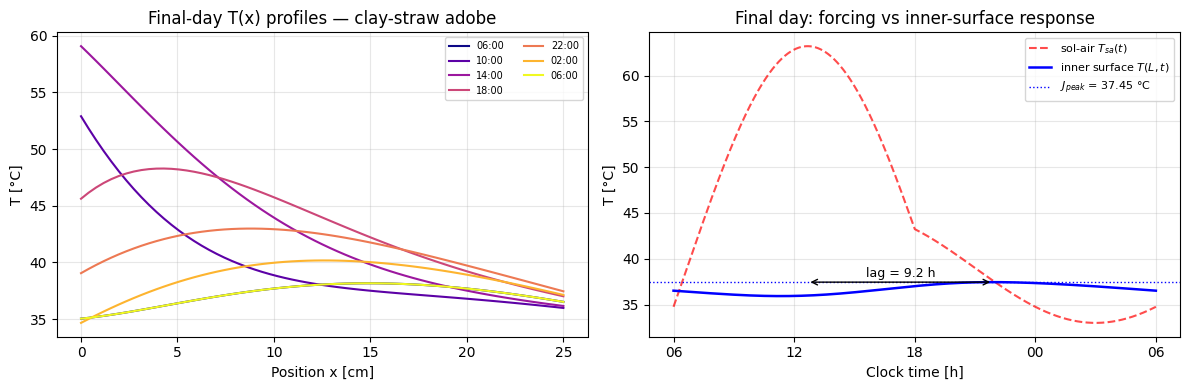

  Saved: transient_sanity_diurnal.png


In [8]:
# CELL: sanity plot
# ================================================================
# SANITY CHECK — final-day solution at nominal diurnal Sindh
# (clay-straw adobe, T_out_max=45 °C, G_peak=700 W/m², w0=15)
# ================================================================
mu_nominal = np.array([0.35, 1400.0, 1000.0, 0.004, 0.25, 15.0, 45.0, 35.0, 700.0])
x_grid, t_save, T_field, met, (t_full, TL, T_sa) = run_fdm_diurnal(
    mu_nominal, return_full_final_day=True)

print(f"  k_eff = {k_eff(0.35, 0.004, 15.0):.4f} W/m/K")
print(f"  J_peak = {met['J_peak']-273.15:.2f} °C   "
      f"time lag = {met['time_lag_h']:.2f} h   "
      f"decrement = {met['decrement']:.4f}   "
      f"periodicity = {met['periodicity_K']:.1e} K")
assert met['J_peak'] >= TL[-1], 'peak must bound the series'
assert 0 < met['decrement'] < 1, 'decrement factor must be in (0,1)'
assert met['time_lag_h'] > 0, 'massive wall must lag the sol-air peak'
print('  Physical checks PASS')

hours = 6 + t_full/3600.0
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
for h in [0, 4, 8, 12, 16, 20, 24]:
    idx = np.argmin(np.abs(t_save/3600.0 - h))
    ax.plot(x_grid*100, T_field[:, idx] - 273.15,
            color=plt.cm.plasma(h/24), label=f'{(6+h) % 24:02.0f}:00')
ax.set_xlabel('Position x [cm]'); ax.set_ylabel('T [°C]')
ax.set_title('Final-day T(x) profiles — clay-straw adobe')
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(hours, T_sa - 273.15, 'r--', label='sol-air $T_{sa}(t)$', alpha=0.7)
ax.plot(hours, TL - 273.15, 'b-', lw=1.8, label='inner surface $T(L,t)$')
ax.axhline(met['J_peak']-273.15, color='b', ls=':', lw=1,
           label=f"$J_{{peak}}$ = {met['J_peak']-273.15:.2f} °C")
ax.annotate('', xy=(6 + t_full[np.argmax(TL)]/3600, TL.max()-273.15),
            xytext=(6 + t_full[np.argmax(T_sa)]/3600, TL.max()-273.15),
            arrowprops=dict(arrowstyle='<->', color='k'))
ax.text(0.5*(12 + t_full[np.argmax(TL)]/3600 + t_full[np.argmax(T_sa)]/3600),
        TL.max()-273.15+0.6, f"lag = {met['time_lag_h']:.1f} h",
        ha='center', fontsize=9)
ax.set_xlabel('Clock time [h]'); ax.set_ylabel('T [°C]')
ax.set_xticks([6, 12, 18, 24, 30]); ax.set_xticklabels(['06','12','18','00','06'])
ax.set_title('Final day: forcing vs inner-surface response')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/content/drive/MyDrive/transient_sanity_diurnal.png', dpi=300, bbox_inches='tight')
plt.show()
print('  Saved: transient_sanity_diurnal.png')

In [9]:
# CELL: material ranking with dynamic metrics
# ================================================================
# MATERIAL RANKING — nominal diurnal Sindh conditions (FDM direct)
# T_out_max=45 °C, G_peak=700 W/m², T_in=35 °C, w0=0, L=0.25 m
# Adds ISO-13786-style dynamic metrics: time lag & decrement factor.
# Writes material_ranking_diurnal.csv (feeds manuscript tables —
# do NOT hard-code these numbers downstream).
# ================================================================
print('='*72)
print('MATERIAL RANKING — nominal diurnal Sindh (FDM ground truth)')
print('='*72)
rank_rows = []
for name, p in MATERIALS.items():
    mu = np.array([p['k_dry'], p['rho'], p['cp'], p['alpha_moist'],
                   0.25, 0.0, 45.0, 35.0, 700.0])
    *_, met = run_fdm_diurnal(mu)
    rank_rows.append((name, met['J_peak']-273.15, met['time_lag_h'],
                      met['decrement'], met['periodicity_K']))
rank_rows.sort(key=lambda r: r[1])
print(f"\n  {'Rank':<5}{'Material':<32}{'J_peak(°C)':>11}{'lag(h)':>8}"
      f"{'decr(-)':>9}{'period(K)':>11}")
print('  ' + '-'*76)
for i, r in enumerate(rank_rows, 1):
    print(f'  {i:<5}{r[0]:<32}{r[1]:>11.2f}{r[2]:>8.2f}{r[3]:>9.4f}{r[4]:>11.1e}')

with open('/content/drive/MyDrive/material_ranking_diurnal.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['rank', 'material', 'J_peak_C', 'time_lag_h',
                'decrement', 'periodicity_K'])
    for i, r in enumerate(rank_rows, 1):
        w.writerow([i, r[0], f'{r[1]:.3f}', f'{r[2]:.3f}',
                    f'{r[3]:.5f}', f'{r[4]:.2e}'])
print('\n  Saved: material_ranking_diurnal.csv')

MATERIAL RANKING — nominal diurnal Sindh (FDM ground truth)

  Rank Material                         J_peak(°C)  lag(h)  decr(-)  period(K)
  ----------------------------------------------------------------------------
  1    Lime-stabilised bamboo panel          36.37   13.43   0.0161    5.7e-03
  2    Clay-straw adobe                      37.07   10.07   0.0386    1.4e-03
  3    Mud brick (unfired)                   37.69    8.80   0.0580    6.2e-04
  4    Lime-mud composite                    38.36    7.69   0.0815    2.1e-04
  5    Fired clay brick                      38.76    7.63   0.0903    2.8e-04

  Saved: material_ranking_diurnal.csv


In [10]:
# CELL: LHS sweep
# ================================================================
# LHS PARAMETRIC SWEEP — N_s = 1500 (production dataset)
# ~10-20 min on Colab CPU with the LU-prefactored solver [C4].
# ================================================================
mu_matrix = generate_lhs_samples()
N_s = len(mu_matrix)

x_grid, t_save, T0, met0 = run_fdm_diurnal(mu_matrix[0])
Nx, N_sav = T0.shape
T_fields  = np.zeros((N_s, Nx, N_sav), dtype=np.float32)
J_series  = np.zeros((N_s, N_sav),     dtype=np.float32)
J_peak    = np.zeros(N_s, dtype=np.float32)
time_lag  = np.zeros(N_s, dtype=np.float32)
decrement = np.zeros(N_s, dtype=np.float32)
period_K  = np.zeros(N_s, dtype=np.float32)

def store(i, Tf, met):
    T_fields[i]  = Tf.astype(np.float32)
    J_series[i]  = Tf[-1, :].astype(np.float32)
    J_peak[i]    = met['J_peak']
    time_lag[i]  = met['time_lag_h']
    decrement[i] = met['decrement']
    period_K[i]  = met['periodicity_K']

store(0, T0, met0)
print(f'LHS SWEEP — {N_s} samples, N_DAYS={N_DAYS}, dt={DAY_S/STEPS_PER_DAY:.1f} s')
t_start = time.time()
for i in range(1, N_s):
    _, _, Ti, met = run_fdm_diurnal(mu_matrix[i])
    store(i, Ti, met)
    if (i+1) % 100 == 0 or i == N_s-1:
        el = time.time() - t_start
        print(f'  [{i+1:4d}/{N_s}]  elapsed={el:.0f}s  '
              f'rate={(i+1)/el:.1f} sim/s  ETA={(N_s-i-1)*el/(i+1):.0f}s')

n_flag = int(np.sum(period_K > 0.05))
print(f'\nPeriodicity across sweep: max={period_K.max():.3e} K, '
      f'median={np.median(period_K):.3e} K, samples > 0.05 K: {n_flag}')
if n_flag > 0:
    print('  WARNING: a few extreme low-diffusivity corners are not fully '
          'periodic at N_DAYS=5.')
    print('  Their periodicity_K is saved with the dataset — either accept '
          '(still well below the')
    print('  PINO error budget) or set N_DAYS = 7 and rerun this cell and the '
          'save cell.')

LHS SWEEP — 1500 samples, N_DAYS=5, dt=21.6 s
  [ 100/1500]  elapsed=59s  rate=1.7 sim/s  ETA=821s
  [ 200/1500]  elapsed=118s  rate=1.7 sim/s  ETA=767s
  [ 300/1500]  elapsed=177s  rate=1.7 sim/s  ETA=707s
  [ 400/1500]  elapsed=234s  rate=1.7 sim/s  ETA=643s
  [ 500/1500]  elapsed=293s  rate=1.7 sim/s  ETA=586s
  [ 600/1500]  elapsed=353s  rate=1.7 sim/s  ETA=530s
  [ 700/1500]  elapsed=413s  rate=1.7 sim/s  ETA=473s
  [ 800/1500]  elapsed=474s  rate=1.7 sim/s  ETA=415s
  [ 900/1500]  elapsed=532s  rate=1.7 sim/s  ETA=355s
  [1000/1500]  elapsed=592s  rate=1.7 sim/s  ETA=296s
  [1100/1500]  elapsed=651s  rate=1.7 sim/s  ETA=237s
  [1200/1500]  elapsed=711s  rate=1.7 sim/s  ETA=178s
  [1300/1500]  elapsed=769s  rate=1.7 sim/s  ETA=118s
  [1400/1500]  elapsed=829s  rate=1.7 sim/s  ETA=59s
  [1500/1500]  elapsed=890s  rate=1.7 sim/s  ETA=0s

Periodicity across sweep: max=4.349e-02 K, median=2.022e-03 K, samples > 0.05 K: 0


In [12]:
# CELL: save dataset
# ================================================================
# SAVE DATASET — sindh_dataset_diurnal.npz
# T_field is the FINAL (periodic) day: (N_s, 65, 121), t in [0, 24 h].
# ================================================================
np.savez_compressed(
    '/content/drive/MyDrive/sindh_dataset_diurnal.npz',
    mu          = mu_matrix.astype(np.float32),
    T_field     = T_fields,
    J_series    = J_series,
    J_peak      = J_peak,
    time_lag_h  = time_lag,
    decrement   = decrement,
    periodicity_K = period_K,
    x_grid      = x_grid.astype(np.float32),
    t_save      = t_save.astype(np.float32),
)
with open('/content/drive/MyDrive/param_names_diurnal.txt', 'w') as f:
    f.write('\n'.join(PARAM_NAMES) + '\n')
    f.write(f'# forcing: G half-sine 06-18h peak=G_s_peak; '
            f'T_out sinusoid max=T_out_max_C at 15:00, swing={DELTA_DIURNAL} K; '
            f'field = final day of {N_DAYS}, t_save from sunrise 06:00\n')

size_mb = os.path.getsize('/content/drive/MyDrive/sindh_dataset_diurnal.npz')/1e6
print(f'Saved: /content/drive/MyDrive/sindh_dataset_diurnal.npz ({size_mb:.1f} MB)')
print(f'Shapes: mu={mu_matrix.shape}, T_field={T_fields.shape}')
print(f'J_peak range: {J_peak.min()-273.15:.1f} – {J_peak.max()-273.15:.1f} °C')
print(f'time lag range: {time_lag.min():.1f} – {time_lag.max():.1f} h; '
      f'decrement range: {decrement.min():.3f} – {decrement.max():.3f}')
print('\nStage 1 (diurnal) complete. Files saved to:')
print('  /content/drive/MyDrive/sindh_dataset_diurnal.npz')
print('  /content/drive/MyDrive/material_ranking_diurnal.csv')
print('  /content/drive/MyDrive/fdm_convergence_diurnal.csv')
print('  /content/drive/MyDrive/diurnal_forcing.png')
print('  /content/drive/MyDrive/transient_sanity_diurnal.png')
print('\nProceed to PINO notebook with these 3 required edits:')
print('  1. data = np.load("/content/drive/MyDrive/sindh_dataset_diurnal.npz")')
print('  2. T_END = 86400.0')
print('  3. def pde_residual_loss(..., T_END=86400.0)')

Saved: /content/drive/MyDrive/sindh_dataset_diurnal.npz (34.7 MB)
Shapes: mu=(1500, 9), T_field=(1500, 65, 121)
J_peak range: 24.9 – 50.0 °C
time lag range: 0.1 – 23.9 h; decrement range: 0.000 – 0.452

Stage 1 (diurnal) complete. Files saved to:
  /content/drive/MyDrive/sindh_dataset_diurnal.npz
  /content/drive/MyDrive/material_ranking_diurnal.csv
  /content/drive/MyDrive/fdm_convergence_diurnal.csv
  /content/drive/MyDrive/diurnal_forcing.png
  /content/drive/MyDrive/transient_sanity_diurnal.png

Proceed to PINO notebook with these 3 required edits:
  1. data = np.load("/content/drive/MyDrive/sindh_dataset_diurnal.npz")
  2. T_END = 86400.0
  3. def pde_residual_loss(..., T_END=86400.0)


## Required edits in the PINO notebook (3 lines) before retraining

1. **Cell 1 (data loading):**
```python
data  = np.load('/content/drive/MyDrive/sindh_dataset_diurnal.npz')
T_END = 86400.0   # final day = 24 h (was 43200.0)
```
2. **Cell 3 (`pde_residual_loss` definition):** change the default argument
```python
def pde_residual_loss(..., T_END=86400.0):
```
Nothing else changes: field shape is still (65, 121), `tau = t_save/T_END` still spans \[0, 1\], input channels are still 11, and the same seeds/architecture/training settings apply.

**Also update (numbers, not code):**
- The hard-coded `J_FDM_C` values in PINO Sections 9–10 must be replaced with the values from `material_ranking_diurnal.csv` produced above (better: load the CSV instead of hard-coding).
- Nominal conditions now mean `T_out_max = 45 °C`, `G_peak = 700 W/m²`.

**Note on the PDE-residual floor (review item 2):** with the periodic final day there is no start-up jump in the saved window; the finite-difference residual of the exact FDM fields drops from ≈ 9.3e-2 to ≈ 2.6e-3 (verified). No early-time masking is needed — train exactly as before, and a larger `λ_T` may now be worth a quick re-check of the {0.001, 0.01, 0.1} grid.

**Manuscript metrics now available per material:** peak inner-surface temperature `J_peak`, **time lag (h)** and **decrement factor (–)** on the periodic day — report all three in the ranking table and cite ISO 13786 for the lag/decrement definitions (simulation-based variant).